In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

In [2]:
df=pd.read_csv("C:/Users/ASUS/Downloads/food_wastage_data.csv")
df

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
0,Meat,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25
1,Meat,400,Birthday,500,Room Temperature,Regular,Winter,Buffet,Suburban,High,40
2,Vegetables,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,27
3,Meat,491,Birthday,497,Refrigerated,Regular,All Seasons,Finger Food,Rural,High,32
4,Meat,300,Corporate,400,Refrigerated,Regular,Winter,Finger Food,Urban,Moderate,25
...,...,...,...,...,...,...,...,...,...,...,...
1777,Baked Goods,310,Corporate,350,Room Temperature,Regular,Summer,Finger Food,Urban,High,35
1778,Baked Goods,284,Social Gathering,443,Room Temperature,Regular,Winter,Buffet,Rural,Low,32
1779,Fruits,220,Wedding,300,Room Temperature,Regular,All Seasons,Finger Food,Urban,Moderate,15
1780,Fruits,250,Wedding,350,Room Temperature,Regular,All Seasons,Finger Food,Rural,Moderate,20


In [3]:
df.shape

(1782, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1782 entries, 0 to 1781
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Type of Food           1782 non-null   object
 1   Number of Guests       1782 non-null   int64 
 2   Event Type             1782 non-null   object
 3   Quantity of Food       1782 non-null   int64 
 4   Storage Conditions     1782 non-null   object
 5   Purchase History       1782 non-null   object
 6   Seasonality            1782 non-null   object
 7   Preparation Method     1782 non-null   object
 8   Geographical Location  1782 non-null   object
 9   Pricing                1782 non-null   object
 10  Wastage Food Amount    1782 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 153.3+ KB


In [6]:
df.head()

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
0,Meat,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25
1,Meat,400,Birthday,500,Room Temperature,Regular,Winter,Buffet,Suburban,High,40
2,Vegetables,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,27
3,Meat,491,Birthday,497,Refrigerated,Regular,All Seasons,Finger Food,Rural,High,32
4,Meat,300,Corporate,400,Refrigerated,Regular,Winter,Finger Food,Urban,Moderate,25


In [8]:
df.describe()

,Number of Guests,Quantity of Food,Wastage Food Amount
count,1782.000000,1782.000000,1782.000000
mean,317.804714,411.125701,28.536476
std,67.829658,65.204674,10.461317
min,207.000000,280.000000,10.000000
25%,267.000000,350.000000,20.000000
50%,302.000000,400.000000,26.500000
75%,350.000000,480.000000,35.000000
max,491.000000,500.000000,63.000000


In [9]:
df.isnull().sum()

Type of Food             0
Number of Guests         0
Event Type               0
Quantity of Food         0
Storage Conditions       0
Purchase History         0
Seasonality              0
Preparation Method       0
Geographical Location    0
Pricing                  0
Wastage Food Amount      0
dtype: int64

In [12]:
desc_stats = df.describe()
desc_stats

,Number of Guests,Quantity of Food,Wastage Food Amount
count,1782.000000,1782.000000,1782.000000
mean,317.804714,411.125701,28.536476
std,67.829658,65.204674,10.461317
min,207.000000,280.000000,10.000000
25%,267.000000,350.000000,20.000000
50%,302.000000,400.000000,26.500000
75%,350.000000,480.000000,35.000000
max,491.000000,500.000000,63.000000


In [10]:
categorical_value_counts = {col: df[col].value_counts() for col in df.select_dtypes(include='object').columns}
categorical_value_counts

{'Type of Food': Meat              437
 Baked Goods       419
 Dairy Products    387
 Fruits            328
 Vegetables        211
 Name: Type of Food, dtype: int64,
 'Event Type': Corporate           515
 Social Gathering    461
 Wedding             438
 Birthday            368
 Name: Event Type, dtype: int64,
 'Storage Conditions': Room Temperature    1157
 Refrigerated         625
 Name: Storage Conditions, dtype: int64,
 'Purchase History': Regular       1576
 Occasional     206
 Name: Purchase History, dtype: int64,
 'Seasonality': Winter         632
 All Seasons    623
 Summer         527
 Name: Seasonality, dtype: int64,
 'Preparation Method': Sit-down Dinner    781
 Finger Food        702
 Buffet             299
 Name: Preparation Method, dtype: int64,
 'Geographical Location': Suburban    821
 Urban       564
 Rural       397
 Name: Geographical Location, dtype: int64,
 'Pricing': High        674
 Moderate    673
 Low         435
 Name: Pricing, dtype: int64}

In [13]:
print(desc_stats)
for column, value_counts in categorical_value_counts.items():
    print(f"\nValue counts for {column}:\n", value_counts)

       Number of Guests  Quantity of Food  Wastage Food Amount
count       1782.000000       1782.000000          1782.000000
mean         317.804714        411.125701            28.536476
std           67.829658         65.204674            10.461317
min          207.000000        280.000000            10.000000
25%          267.000000        350.000000            20.000000
50%          302.000000        400.000000            26.500000
75%          350.000000        480.000000            35.000000
max          491.000000        500.000000            63.000000

Value counts for Type of Food:
 Meat              437
Baked Goods       419
Dairy Products    387
Fruits            328
Vegetables        211
Name: Type of Food, dtype: int64

Value counts for Event Type:
 Corporate           515
Social Gathering    461
Wedding             438
Birthday            368
Name: Event Type, dtype: int64

Value counts for Storage Conditions:
 Room Temperature    1157
Refrigerated         625
Name: Stor

In [14]:
# Convert categorical columns to numerical using One-Hot Encoding
data_encoded = pd.get_dummies(df, drop_first=True)

print("Data after One-Hot Encoding:")
print(data_encoded.head())

Data after One-Hot Encoding:
   Number of Guests  Quantity of Food  Wastage Food Amount  \
0               310               450                   25   
1               400               500                   40   
2               302               371                   27   
3               491               497                   32   
4               300               400                   25   

   Type of Food_Dairy Products  Type of Food_Fruits  Type of Food_Meat  \
0                            0                    0                  1   
1                            0                    0                  1   
2                            0                    0                  0   
3                            0                    0                  1   
4                            0                    0                  1   

   Type of Food_Vegetables  Event Type_Corporate  Event Type_Social Gathering  \
0                        0                     1                        

Correlation Matrix:
                                     Number of Guests  Quantity of Food  \
Number of Guests                             1.000000          0.794401   
Quantity of Food                             0.794401          1.000000   
Wastage Food Amount                          0.650421          0.638648   
Type of Food_Dairy Products                 -0.025518         -0.039056   
Type of Food_Fruits                          0.030943          0.027762   
Type of Food_Meat                           -0.001936          0.024453   
Type of Food_Vegetables                     -0.037647         -0.035452   
Event Type_Corporate                        -0.022645         -0.004648   
Event Type_Social Gathering                 -0.034600         -0.038155   
Event Type_Wedding                           0.028284          0.047745   
Storage Conditions_Room Temperature         -0.006053         -0.047273   
Purchase History_Regular                     0.009544         -0.011688   
Seaso

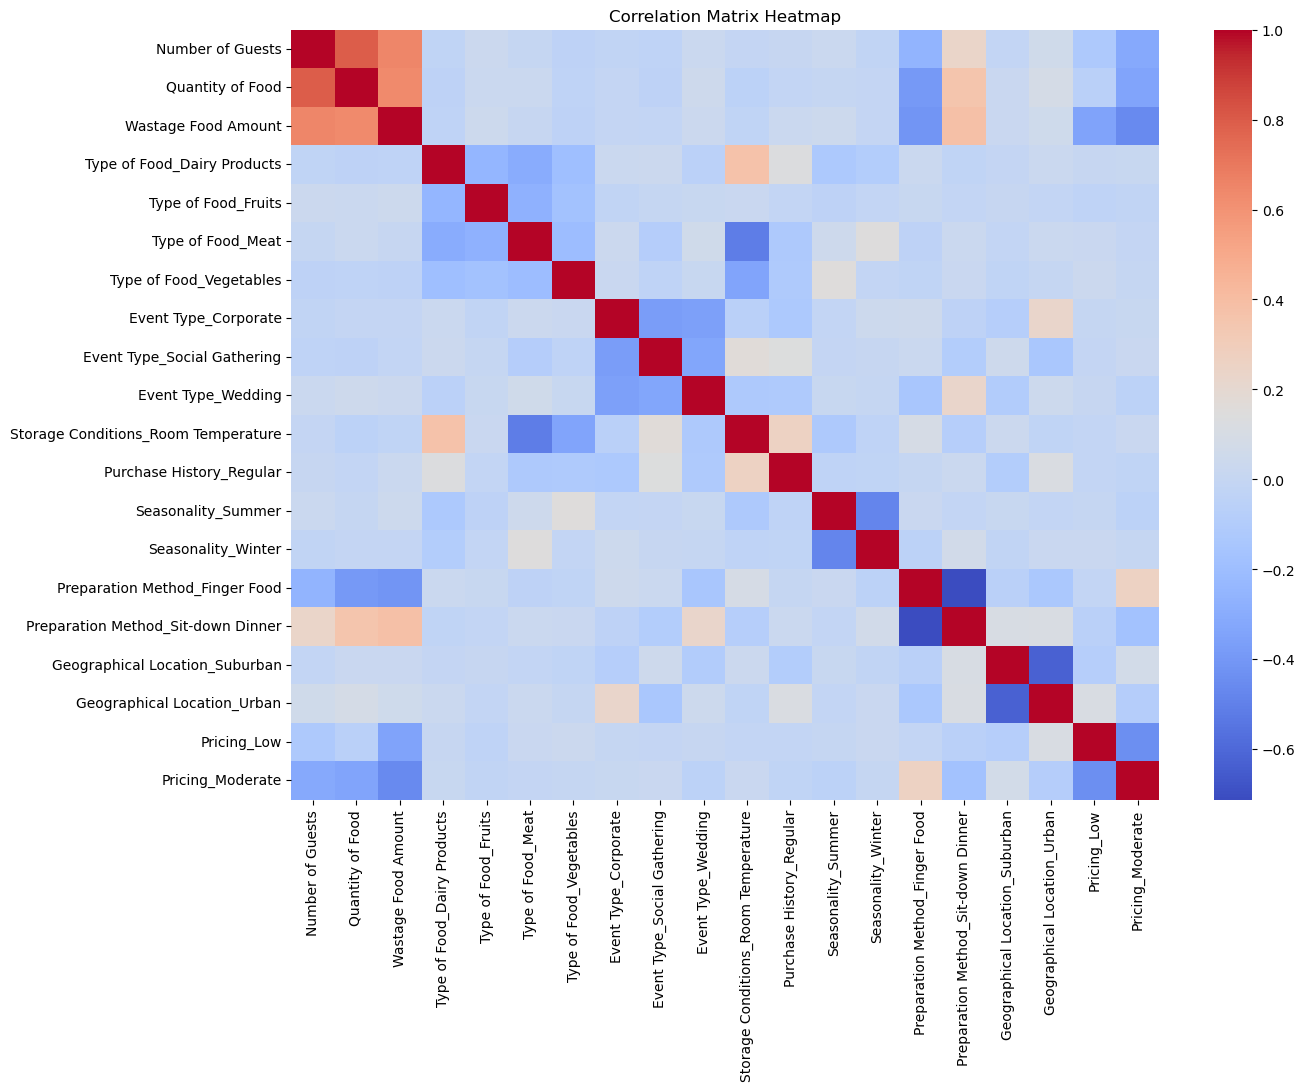

In [15]:
correlation_matrix = data_encoded.corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix as a heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f", cbar=True)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [16]:
# Compute the correlation matrix
correlation_matrix = data_encoded.corr()

# Convert correlation matrix to a tidy table (melted format)
correlation_table = correlation_matrix.unstack().reset_index()
correlation_table.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Remove self-correlations (correlation = 1.0 for same features)
correlation_table = correlation_table[correlation_table['Feature 1'] != correlation_table['Feature 2']]

# Filter only negative correlations
negative_correlations = correlation_table[correlation_table['Correlation'] < 0]

# Sort by correlation values
negative_correlations = negative_correlations.sort_values(by='Correlation', ascending=False)

# Display the top positive correlations
print("Negative Correlation Table:")
print(negative_correlations.head(20))

Negative Correlation Table:
                          Feature 1                       Feature 2  \
193              Event Type_Wedding              Seasonality_Winter   
269              Seasonality_Winter              Event Type_Wedding   
5                  Number of Guests               Type of Food_Meat   
100               Type of Food_Meat                Number of Guests   
386                Pricing_Moderate         Type of Food_Vegetables   
139         Type of Food_Vegetables                Pricing_Moderate   
241              Seasonality_Summer                Quantity of Food   
32                 Quantity of Food              Seasonality_Summer   
137         Type of Food_Vegetables     Geographical Location_Urban   
346     Geographical Location_Urban         Type of Food_Vegetables   
76      Type of Food_Dairy Products  Geographical Location_Suburban   
323  Geographical Location_Suburban     Type of Food_Dairy Products   
261              Seasonality_Winter              

In [19]:
negative_feature_pairs = negative_correlations[['Feature 1', 'Feature 2']].values.flatten()
selected_features = list(set(negative_feature_pairs))  # Remove duplicates

In [20]:
selected_features

['Geographical Location_Suburban',
 'Purchase History_Regular',
 'Preparation Method_Finger Food',
 'Wastage Food Amount',
 'Event Type_Wedding',
 'Pricing_Moderate',
 'Type of Food_Dairy Products',
 'Number of Guests',
 'Seasonality_Winter',
 'Pricing_Low',
 'Type of Food_Meat',
 'Seasonality_Summer',
 'Storage Conditions_Room Temperature',
 'Event Type_Social Gathering',
 'Type of Food_Fruits',
 'Type of Food_Vegetables',
 'Preparation Method_Sit-down Dinner',
 'Geographical Location_Urban',
 'Quantity of Food',
 'Event Type_Corporate']

In [21]:
selected_features.append('Wastage Food Amount')  # Add the target column

In [22]:
training_data = data_encoded[selected_features]

In [23]:
X = training_data.drop('Wastage Food Amount', axis=1)  # Features
y = training_data['Wastage Food Amount']  # Target

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
X

,Geographical Location_Suburban,Purchase History_Regular,Preparation Method_Finger Food,Event Type_Wedding,Pricing_Moderate,Type of Food_Dairy Products,Number of Guests,Seasonality_Winter,Pricing_Low,Type of Food_Meat,Seasonality_Summer,Storage Conditions_Room Temperature,Event Type_Social Gathering,Type of Food_Fruits,Type of Food_Vegetables,Preparation Method_Sit-down Dinner,Geographical Location_Urban,Quantity of Food,Event Type_Corporate
0,0,1,0,0,0,0,310,0,1,1,0,0,0,0,0,0,1,450,1
1,1,1,0,0,0,0,400,1,0,1,0,1,0,0,0,0,0,500,0
2,1,1,0,0,0,0,302,0,1,0,1,0,0,0,1,0,0,371,0
3,0,1,1,0,0,0,491,0,0,1,0,0,0,0,0,0,0,497,0
4,0,1,1,0,1,0,300,1,0,1,0,0,0,0,0,0,1,400,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1777,0,1,1,0,0,0,310,0,0,0,1,1,0,0,0,0,1,350,1
1778,0,1,0,0,0,0,284,1,1,0,0,1,1,0,0,0,0,443,0
1779,0,1,1,1,1,0,220,0,0,0,0,1,0,1,0,0,1,300,0
1780,0,1,1,1,1,0,250,0,0,0,0,1,0,1,0,0,0,350,0


In [26]:
y

,Wastage Food Amount,Wastage Food Amount
0,25,25
1,40,40
2,27,27
3,32,32
4,25,25
...,...,...
1777,35,35
1778,32,32
1779,15,15
1780,20,20


In [27]:
# Assuming 'Wastage Food Amount' is the target column, ensuring it's 1D
y = training_data['Wastage Food Amount']  # Ensure it's a 1D array with the correct target

# If duplicate columns exist, drop one
if y.shape[1] > 1:
    y = y.iloc[:, 0]  # Keep only the first column if there are duplicates

In [28]:
y

0       25
1       40
2       27
3       32
4       25
        ..
1777    35
1778    32
1779    15
1780    20
1781    45
Name: Wastage Food Amount, Length: 1782, dtype: int64

In [29]:
print(training_data.columns)

Index(['Geographical Location_Suburban', 'Purchase History_Regular',
       'Preparation Method_Finger Food', 'Wastage Food Amount',
       'Event Type_Wedding', 'Pricing_Moderate', 'Type of Food_Dairy Products',
       'Number of Guests', 'Seasonality_Winter', 'Pricing_Low',
       'Type of Food_Meat', 'Seasonality_Summer',
       'Storage Conditions_Room Temperature', 'Event Type_Social Gathering',
       'Type of Food_Fruits', 'Type of Food_Vegetables',
       'Preparation Method_Sit-down Dinner', 'Geographical Location_Urban',
       'Quantity of Food', 'Event Type_Corporate', 'Wastage Food Amount'],
      dtype='object')


In [30]:
training_data = training_data.loc[:, ~training_data.columns.duplicated()]

In [31]:
training_data

,Geographical Location_Suburban,Purchase History_Regular,Preparation Method_Finger Food,Wastage Food Amount,Event Type_Wedding,Pricing_Moderate,Type of Food_Dairy Products,Number of Guests,Seasonality_Winter,Pricing_Low,Type of Food_Meat,Seasonality_Summer,Storage Conditions_Room Temperature,Event Type_Social Gathering,Type of Food_Fruits,Type of Food_Vegetables,Preparation Method_Sit-down Dinner,Geographical Location_Urban,Quantity of Food,Event Type_Corporate
0,0,1,0,25,0,0,0,310,0,1,1,0,0,0,0,0,0,1,450,1
1,1,1,0,40,0,0,0,400,1,0,1,0,1,0,0,0,0,0,500,0
2,1,1,0,27,0,0,0,302,0,1,0,1,0,0,0,1,0,0,371,0
3,0,1,1,32,0,0,0,491,0,0,1,0,0,0,0,0,0,0,497,0
4,0,1,1,25,0,1,0,300,1,0,1,0,0,0,0,0,0,1,400,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1777,0,1,1,35,0,0,0,310,0,0,0,1,1,0,0,0,0,1,350,1
1778,0,1,0,32,0,0,0,284,1,1,0,0,1,1,0,0,0,0,443,0
1779,0,1,1,15,1,1,0,220,0,0,0,0,1,0,1,0,0,1,300,0
1780,0,1,1,20,1,1,0,250,0,0,0,0,1,0,1,0,0,0,350,0


In [32]:
y = training_data['Wastage Food Amount']

In [33]:
print(y.shape)

(1782,)


In [34]:
X = training_data.drop('Wastage Food Amount', axis=1)  # Features

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
log_reg_model = LogisticRegression(random_state=42)
svm_model = SVC(probability=True, random_state=42)

# Train and predict with Random Forest
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]  # For probability-based evaluation (like ROC AUC)

# Train and predict with Logistic Regression
log_reg_model.fit(X_train, y_train)
log_reg_pred = log_reg_model.predict(X_test)
log_reg_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

# Train and predict with SVM
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_pred_proba = svm_model.predict_proba(X_test)[:, 1]

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [43]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Model Performance:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

# Evaluate each model
evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("Logistic Regression", y_test, log_reg_pred)
evaluate_model("SVM", y_test, svm_pred)



Random Forest Model Performance:
Accuracy: 0.7563025210084033
Confusion Matrix:
 [[ 4  1  0  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 34  0  8  0  0  0  7  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  6  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  1  0 59  0  0  0  8  0  1  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  7  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  0  0  1  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  1  0  3  0  0  0 32  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  2  0  0  0  0  3  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  3  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  0  0  0  4  0  0 32  0  1  0  0  0  0  1  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  2  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  1  0  0  0  0  8  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\Lib\site-packages\s

Metrics for Random Forest:
Accuracy: 0.7619
Precision: 0.8272
Recall: 0.7370
F1-Score: 0.7619


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


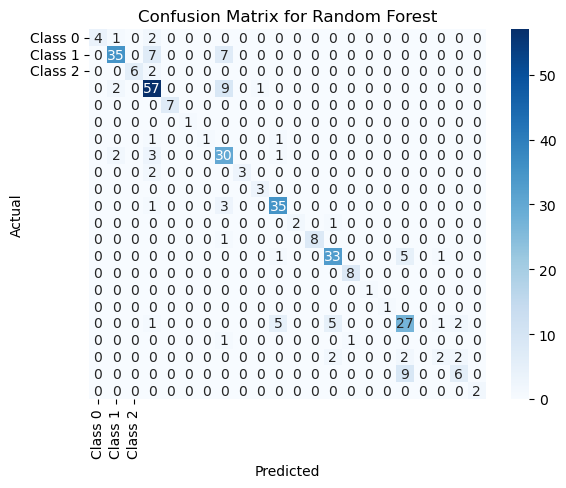

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1146: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


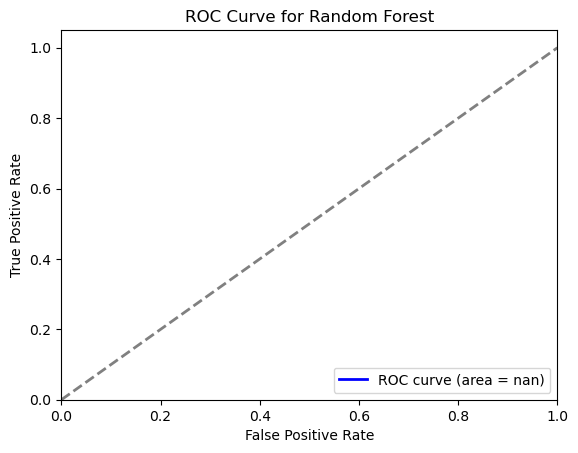


--------------------------------------------------


In [37]:
print_metrics("Random Forest", y_test, rf_pred)

Metrics for SVM:
Accuracy: 0.3613
Precision: 0.1159
Recall: 0.1356
F1-Score: 0.1148


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


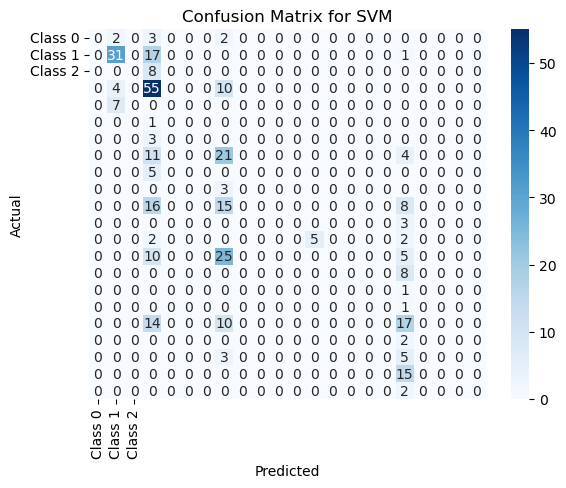

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1146: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


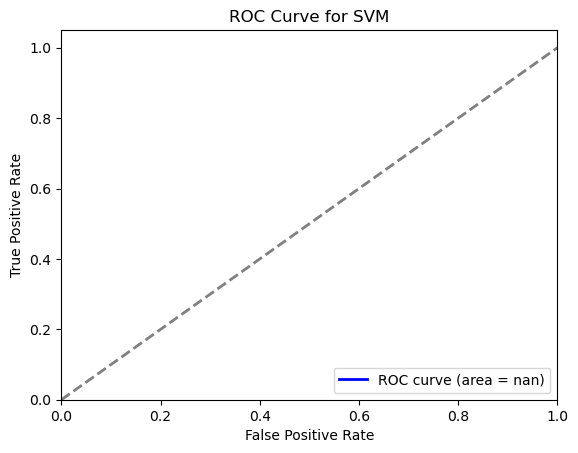


--------------------------------------------------


In [38]:
print_metrics("SVM", y_test, svm_pred)

Metrics for Logistic Regression:
Accuracy: 0.2017
Precision: 0.0466
Recall: 0.0838
F1-Score: 0.0546


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


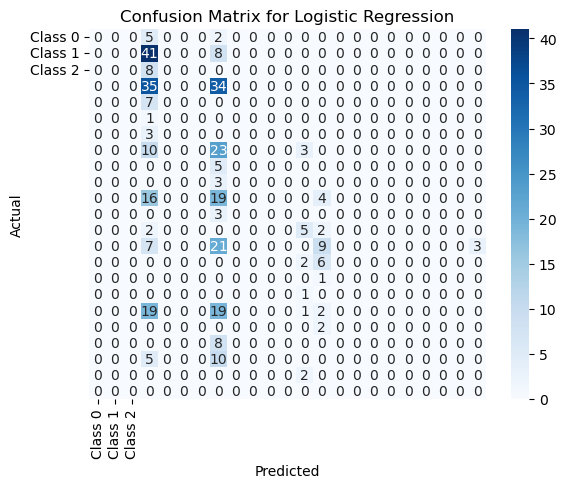

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1146: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


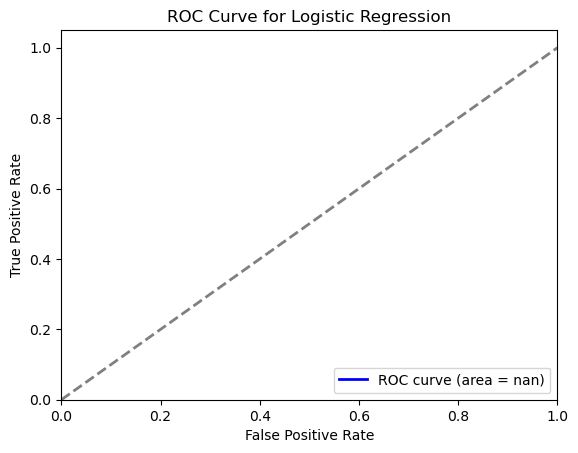


--------------------------------------------------


In [39]:
print_metrics("Logistic Regression", y_test, log_reg_pred)